# Assignment 01 — Mapping the global submarine cable network

**Research question:** What does the geography and age of the global submarine cable
network reveal about the spatial concentration and continuing expansion of digital
infrastructure?

This notebook maps submarine cable routes worldwide and explores two attributes in
particular: the **ready-for-service year** (`rfs_year`) and whether a cable is
**planned or already in service** (`is_planned`). The analysis uses the public API of
TeleGeography's Submarine Cable Map, linked from the Copernicus Marine product
`EXT_TELEGEOGRAPHY_SUBMARINE_CABLES`.

Sources:

- Copernicus Marine product description: https://data.marine.copernicus.eu/product/EXT_TELEGEOGRAPHY_SUBMARINE_CABLES/description
- Cable geometries: https://www.submarinecablemap.com/api/v3/cable/cable-geo.json
- Cable metadata index: https://www.submarinecablemap.com/api/v3/cable/all.json


## 1. Setup

The analysis uses GeoPandas for spatial data, pandas for tabular analysis, and
Matplotlib for the map and charts. If an import fails, install the missing packages
in the active notebook kernel before continuing.


In [2]:
from concurrent.futures import ThreadPoolExecutor, as_completed
from pathlib import Path
import json
import re
import time

import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib import font_manager
from matplotlib.lines import Line2D
from matplotlib.path import Path as MarkerPath
import numpy as np
import pandas as pd
import requests
from shapely import contains_xy
import xarray as xr

pd.set_option("display.max_columns", 30)

PROJECT_ASSIGNMENTS = Path("cdp-mapping-systems/content/Assignments")
ASSIGNMENTS_DIR = PROJECT_ASSIGNMENTS if PROJECT_ASSIGNMENTS.exists() else Path(".")
DATA_DIR = ASSIGNMENTS_DIR / "01-Data/marine-cables"
DATA_DIR.mkdir(parents=True, exist_ok=True)

FONT_FILE = ASSIGNMENTS_DIR / "assets/fonts/CascadiaCode/CascadiaCode.ttf"
font_manager.fontManager.addfont(FONT_FILE)
FONT_FAMILY = font_manager.FontProperties(fname=FONT_FILE).get_name()
plt.rcParams["font.family"] = FONT_FAMILY

GEOMETRY_URL = "https://www.submarinecablemap.com/api/v3/cable/cable-geo.json"
INDEX_URL = "https://www.submarinecablemap.com/api/v3/cable/all.json"
DETAIL_URL = "https://www.submarinecablemap.com/api/v3/cable/{cable_id}.json"

GEOMETRY_FILE = DATA_DIR / "cable-geo.json"
METADATA_FILE = DATA_DIR / "cable-metadata.json"
OCEAN_FILE = DATA_DIR / "copernicus_surface_biogeochemistry_2026-08-05.nc"
BATHYMETRY_FILE = DATA_DIR / "gmrt_global_topography.nc"
EBSA_FILE = ASSIGNMENTS_DIR / "01-Data/ebsa/ebsa_repository.geojson"


## 2. Download and cache the route geometries

The API is a changing live source. To make the analysis reproducible within this
project, the downloaded response is saved locally. Deleting the cached file and
rerunning the cell will retrieve a newer snapshot.


In [3]:
def download_if_missing(url, destination):
    if destination.exists():
        print(f"Using cached file: {destination}")
        return

    response = requests.get(url, timeout=60)
    response.raise_for_status()
    destination.write_bytes(response.content)
    print(f"Downloaded: {destination} ({destination.stat().st_size:,} bytes)")


download_if_missing(GEOMETRY_URL, GEOMETRY_FILE)
cables = gpd.read_file(GEOMETRY_FILE)
cables = cables.set_crs("EPSG:4326", allow_override=True)

print(f"Cable route features: {len(cables):,}")
print(f"CRS: {cables.crs}")
print(f"Geometry types: {cables.geometry.geom_type.value_counts().to_dict()}")
cables.head()


Using cached file: 01-Data\marine-cables\cable-geo.json
Cable route features: 718
CRS: EPSG:4326
Geometry types: {'MultiLineString': 718}


c:\Users\ASUS\anaconda3\envs\cdp\Lib\site-packages\pyogrio\core.py:34: RuntimeWarning: Could not detect GDAL data files. Set GDAL_DATA environment variable to the correct path.
  _init_gdal_data()


,id,name,color,feature_id,coordinates,geometry
0,ion-cable-system-1-ics1,ION Cable System-1 (ICS1),#939597,ion-cable-system-1-ics1-0,"[103.62113910767192, -0.7804989614927819]","MULTILINESTRING ((104.01664 1.0668, 104.1496 0..."
1,i-2sea,I-2SEA,#939597,i-2sea-0,"[92.98084574162337, 9.925274018780092]","MULTILINESTRING ((81.13952 16.17505, 83.69933 ..."
2,mvista,MViSTA,#939597,mvista-0,"[101.45127177572613, 8.699863910548952]","MULTILINESTRING ((101.27734 12.67066, 101.2772..."
3,bernacchi-1,Bernacchi-1,#939597,bernacchi-1-0,"[146.63868175101098, -40.320453683968964]","MULTILINESTRING ((146.24997 -39.68895, 146.631..."
4,kunoa-north,Kunoa North,#939597,kunoa-north-0,"[-156.96656308826877, 21.295721056114605]","MULTILINESTRING ((-159.40533 22.21511, -159.11..."


### Initial attribute inspection

The geometry endpoint contains route shapes plus a small set of descriptive fields.
`id` identifies the cable system, while `feature_id` distinguishes geometry features.
Multiple geometry features may therefore refer to the same cable system. This means
the number of rows should not automatically be interpreted as the number of cables.


In [4]:
scalar_attributes = cables.drop(columns=["geometry", "coordinates"], errors="ignore")
attribute_summary = pd.DataFrame({
    "dtype": scalar_attributes.dtypes.astype(str),
    "missing": scalar_attributes.isna().sum(),
    "unique": scalar_attributes.nunique(dropna=True),
})
attribute_summary


,dtype,missing,unique
id,str,0,697
name,str,0,697
color,str,0,542
feature_id,str,0,718


In [5]:
print(f"Geometry features: {len(cables):,}")
print(f"Unique cable IDs: {cables['id'].nunique():,}")
print("Spatial bounds [west, south, east, north]:")
print(cables.total_bounds)


Geometry features: 718
Unique cable IDs: 697
Spatial bounds [west, south, east, north]:
[-179.99981351  -55.00636394  179.99996032   79.0210206 ]


## 3. Global map with surface chlorophyll

Each line represents a generalized cable route supplied by TeleGeography. The map
reveals the spatial structure of the network: dense corridors connect major coastal
regions, while some ocean areas have comparatively few routes. The background layer is
Copernicus Marine total chlorophyll (`chl`) for 5 August 2026 at approximately 0.49 m
depth. Five fuchsia pattern densities represent relative chlorophyll quantiles, from
very low to very high concentrations, without using a continuous color gradient. Thin
grey bathymetric contours derived from the GMRT global topography grid show seafloor
depths at -8000, -6000, -4000, -2000, -1000, -500, -200, and -100 metres.

Line overlap is meaningful as an indication of mapped route concentration, but it is
not a direct measurement of bandwidth, traffic, redundancy, or economic importance. The
chlorophyll field is a single-day model product and should not be interpreted as a
long-term ecological average or as a causal explanation for cable locations.


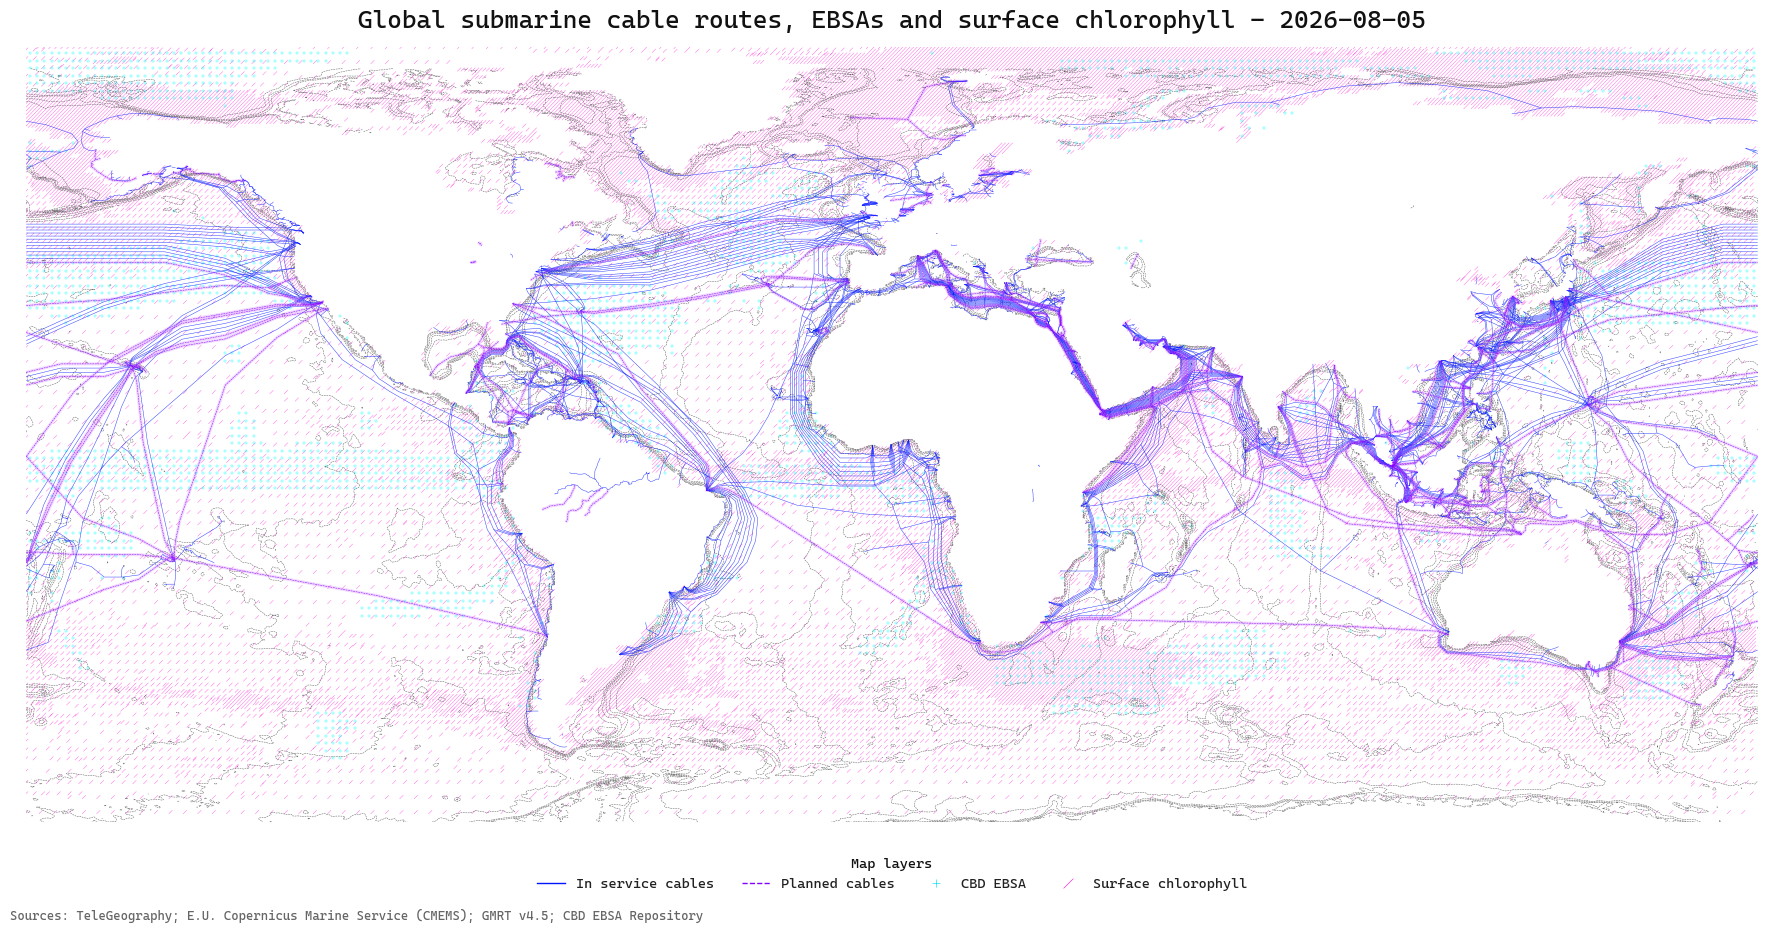

Rendered cable routes — in service: 627; planned in violet: 91


In [13]:
ocean = xr.open_dataset(OCEAN_FILE)
chlorophyll = ocean["chl"].isel(time=0, depth=0).where(ocean["chl"].isel(time=0, depth=0) > 0).load()
chlorophyll_date = pd.to_datetime(ocean["time"].values[0]).strftime("%Y-%m-%d")
chlorophyll_depth = float(ocean["depth"].values[0])
pattern_levels = [
    float(chlorophyll.quantile(q, skipna=True))
    for q in [0.0, 0.2, 0.4, 0.6, 0.8, 1.0]
]
pattern_labels = ["Very low", "Low", "Medium", "High", "Very high"]
pattern_strides = [12, 9, 7, 5, 3]  # smaller stride = closer marks
slash_marker = MarkerPath([[-0.5, -0.5], [0.5, 0.5]], [MarkerPath.MOVETO, MarkerPath.LINETO])

ebsa = gpd.read_file(EBSA_FILE).set_crs("OGC:CRS84", allow_override=True)

# Match every route to the planned/in-service status supplied by TeleGeography
map_metadata = pd.DataFrame(
    json.loads(METADATA_FILE.read_text(encoding="utf-8"))["records"]
)[["id", "is_planned"]]
cables_by_status = cables.merge(map_metadata, on="id", how="left")
in_service_cables = cables_by_status[~cables_by_status["is_planned"].fillna(False)]
planned_cables = cables_by_status[cables_by_status["is_planned"].eq(True)]

gmrt = xr.open_dataset(BATHYMETRY_FILE)
gmrt_width, gmrt_height = [int(value) for value in gmrt["dimension"].values]
gmrt_longitude = np.linspace(gmrt["x_range"].values[0], gmrt["x_range"].values[1], gmrt_width)
gmrt_latitude = np.linspace(gmrt["y_range"].values[1], gmrt["y_range"].values[0], gmrt_height)
gmrt_elevation = gmrt["z"].values.reshape(gmrt_height, gmrt_width)
gmrt_bathymetry = np.where(gmrt_elevation < 0, gmrt_elevation, np.nan)
bathymetry_levels = [-8000, -6000, -4000, -2000, -1000, -500, -200, -100]

fig, ax = plt.subplots(figsize=(18, 9), facecolor="white")
ax.set_facecolor("white")

longitude_grid, latitude_grid = np.meshgrid(ocean["longitude"].values, ocean["latitude"].values)
chlorophyll_values = chlorophyll.values
for class_index, stride in enumerate(pattern_strides):
    sample = (slice(None, None, stride), slice(None, None, stride))
    sampled_values = chlorophyll_values[sample]
    lower = pattern_levels[class_index]
    upper = pattern_levels[class_index + 1]
    if class_index == len(pattern_strides) - 1:
        class_mask = (sampled_values >= lower) & (sampled_values <= upper)
    else:
        class_mask = (sampled_values >= lower) & (sampled_values < upper)
    class_mask &= np.isfinite(sampled_values)
    ax.scatter(
        longitude_grid[sample][class_mask],
        latitude_grid[sample][class_mask],
        marker=slash_marker,
        s=7,
        facecolors="none",
        edgecolors="#FF00D4",
        linewidths=0.28,
        alpha=0.72,
        zorder=0,
    )

# GMRT bathymetric contours
ax.contour(
    gmrt_longitude,
    gmrt_latitude,
    gmrt_bathymetry,
    levels=bathymetry_levels,
    colors="#5A5A5A",
    linewidths=0.34,
)

# CBD EBSAs: small cyan crosses, without polygon borders
ebsa_pattern_geometry = ebsa.geometry.make_valid().union_all()
ebsa_pattern_longitudes = np.arange(-179.25, 180, 1.5)
ebsa_pattern_latitudes = np.arange(-69.25, 85, 1.5)
ebsa_pattern_x, ebsa_pattern_y = np.meshgrid(
    ebsa_pattern_longitudes, ebsa_pattern_latitudes
)
ebsa_pattern_mask = contains_xy(
    ebsa_pattern_geometry,
    ebsa_pattern_x.ravel(),
    ebsa_pattern_y.ravel(),
)
ax.scatter(
    ebsa_pattern_x.ravel()[ebsa_pattern_mask],
    ebsa_pattern_y.ravel()[ebsa_pattern_mask],
    marker="+",
    s=7,
    color="#00FFFB",
    linewidths=0.34,
    alpha=0.72,
    zorder=0.8,
)

# Existing cable routes in electric blue
in_service_cables.plot(
    ax=ax,
    color="#0015FF",
    linewidth=0.35,
    alpha=0.82,
    zorder=2,
)

# Planned future cable routes: violet glow and crisp foreground
planned_cables.plot(
    ax=ax,
    color="#C45CFF",
    linewidth=2.2,
    alpha=0.24,
    zorder=2.8,
)
planned_cables.plot(
    ax=ax,
    color="#8300FF",
    linewidth=0.35,
    linestyle="--",
    alpha=1.0,
    zorder=3,
)

ax.set_xlim(-180, 180)
ax.set_ylim(-70, 85)
ax.set_title(
    f"Global submarine cable routes, EBSAs and surface chlorophyll - {chlorophyll_date}",
    color="#111111",
    fontsize=18,
    pad=14,
)
ebsa_handle = Line2D(
    [0], [0], linestyle="none", marker="+", markersize=6,
    markeredgewidth=0.45, color="#00DFF2", label="CBD EBSA",
)
cable_handles = [
    Line2D([0], [0], color="#0015FF", linewidth=1, label="In service cables"),
    Line2D([0], [0], color="#8300FF", linewidth=1, linestyle="--", label="Planned cables"),
]
chlorophyll_handle = Line2D(
    [0], [0], linestyle="none", marker=slash_marker, markersize=7,
    markeredgewidth=0.4, markeredgecolor="#FF00D4",
    label="Surface chlorophyll",
)
legend = ax.legend(
    handles=[*cable_handles, ebsa_handle, chlorophyll_handle],
    title="Map layers",
    loc="lower center",
    bbox_to_anchor=(0.5, -0.105),
    ncol=4,
    frameon=False,
)
plt.setp(legend.get_texts(), color="#222222")
legend.get_title().set_color("#111111")
fig.text(
    0.01,
    0.01,
    "Sources: TeleGeography; E.U. Copernicus Marine Service (CMEMS); GMRT v4.5; CBD EBSA Repository",
    color="#666666",
    fontsize=9,
)
ax.set_axis_off()
plt.tight_layout(rect=[0, 0.075, 1, 1])
ocean.close()
gmrt.close()
plt.show()

print(
    f"Rendered cable routes — in service: {len(in_service_cables):,}; "
    f"planned in violet: {len(planned_cables):,}"
)


## 4. Retrieve descriptive metadata

The route GeoJSON does not contain dates or operational status. Those attributes are
available through one detail endpoint per cable. The following cell downloads the
metadata concurrently and saves the result as a local cache. Depending on the network,
the first run may take several minutes; later runs use the saved file.

Failed requests are recorded rather than silently discarded. A small number of missing
records would therefore remain visible as a limitation of the snapshot.


In [7]:
def fetch_cable_detail(cable_id, attempts=3):
    url = DETAIL_URL.format(cable_id=cable_id)
    for attempt in range(attempts):
        try:
            response = requests.get(url, timeout=30)
            response.raise_for_status()
            return response.json(), None
        except requests.RequestException as exc:
            if attempt == attempts - 1:
                return None, {"id": cable_id, "error": str(exc)}
            time.sleep(1.5 * (attempt + 1))


if METADATA_FILE.exists():
    metadata_payload = json.loads(METADATA_FILE.read_text(encoding="utf-8"))
    print(f"Using cached file: {METADATA_FILE}")
else:
    index_response = requests.get(INDEX_URL, timeout=60)
    index_response.raise_for_status()
    cable_index = index_response.json()
    cable_ids = sorted({item["id"] for item in cable_index})

    records = []
    errors = []
    with ThreadPoolExecutor(max_workers=8) as executor:
        futures = {
            executor.submit(fetch_cable_detail, cable_id): cable_id
            for cable_id in cable_ids
        }
        for future in as_completed(futures):
            record, error = future.result()
            if record is not None:
                records.append(record)
            if error is not None:
                errors.append(error)

    metadata_payload = {
        "source": INDEX_URL,
        "records": sorted(records, key=lambda item: item["id"]),
        "errors": errors,
    }
    METADATA_FILE.write_text(
        json.dumps(metadata_payload, ensure_ascii=False, indent=2),
        encoding="utf-8",
    )
    print(f"Saved metadata cache: {METADATA_FILE}")

metadata = pd.DataFrame(metadata_payload["records"])
print(f"Metadata records: {len(metadata):,}")
print(f"Failed requests: {len(metadata_payload.get('errors', [])):,}")
metadata.head()


Using cached file: 01-Data\marine-cables\cable-metadata.json
Metadata records: 697
Failed requests: 0


,id,name,length,landing_points,owners,suppliers,rfs,rfs_year,is_planned,url,notes
0,2africa,2Africa,"45,000 km","[{'id': 'luanda-angola', 'name': 'Luanda, Ango...","Bayobab, China Mobile, Meta, Orange, Telecom E...",ASN,2024,2024.0,False,https://www.2africacable.net/,NaN
1,5-villages-6-islands,5 Villages 6 Islands,355 km,"[{'id': 'aogashima-japan', 'name': 'Aogashima,...",Tokyo Metropolitan Government,NEC,2019,2019.0,False,NaN,NaN
2,acs-alaska-oregon-network-akorn,ACS Alaska-Oregon Network (AKORN),"3,000 km","[{'id': 'anchorage-ak-united-states', 'name': ...",Alaska Communications,SubCom,2009 April,2009.0,False,https://www.alaskacommunications.com,NaN
3,adamasia-cable-system-1,Adamasia Cable System 1,"1,015 km","[{'id': 'honiara-solomon-islands', 'name': 'Ho...",Solomon Island Submarine Cable Company,SubCom,2027 Q4,2027.0,True,NaN,NaN
4,aden-djibouti,Aden-Djibouti,269 km,"[{'id': 'djibouti-city-djibouti', 'name': 'Dji...","Djibouti Telecom, Orange, Sparkle, Tata Commun...",ASN,1994,1994.0,False,https://www.teleyemen.com.ye/,NaN


## 5. Clean and join the attributes

The published cable length is text such as `"45,000 km"`; it is converted into a
numeric value for summary statistics. Metadata are joined to the geometries using the
cable `id`. We keep in mind that a single cable can have more than one route feature,
so cable-level charts must use the metadata table rather than the geometry rows.


In [8]:
def parse_length_km(value):
    if pd.isna(value):
        return pd.NA
    match = re.search(r"[0-9,]+", str(value))
    if not match:
        return pd.NA
    return float(match.group(0).replace(",", ""))


metadata["length_km"] = metadata["length"].apply(parse_length_km).astype("Float64")
metadata["rfs_year"] = pd.to_numeric(metadata["rfs_year"], errors="coerce").astype("Int64")
metadata["status"] = metadata["is_planned"].map({True: "Planned", False: "In service"})

cable_routes = cables.merge(
    metadata.drop(columns="landing_points", errors="ignore"),
    on="id",
    how="left",
    suffixes=("_geometry", "_metadata"),
)

print(f"Geometry features with an RFS year: {cable_routes['rfs_year'].notna().sum():,}")
metadata[["name", "rfs_year", "status", "length_km", "owners", "suppliers"]].head()


Geometry features with an RFS year: 713


,name,rfs_year,status,length_km,owners,suppliers
0,2Africa,2024,In service,45000.0,"Bayobab, China Mobile, Meta, Orange, Telecom E...",ASN
1,5 Villages 6 Islands,2019,In service,355.0,Tokyo Metropolitan Government,NEC
2,ACS Alaska-Oregon Network (AKORN),2009,In service,3000.0,Alaska Communications,SubCom
3,Adamasia Cable System 1,2027,Planned,1015.0,Solomon Island Submarine Cable Company,SubCom
4,Aden-Djibouti,1994,In service,269.0,"Djibouti Telecom, Orange, Sparkle, Tata Commun...",ASN


In [9]:
metadata[["rfs_year", "length_km"]].describe().round(1)


,rfs_year,length_km
count,692.0,627.0
mean,2012.6,3079.5
std,10.8,5642.6
min,1989.0,3.0
25%,2003.0,207.0
50%,2014.0,740.0
75%,2022.0,2885.5
max,2029.0,50000.0


## 6. Non-map visualization: cables by ready-for-service year

`rfs_year` records when a system was, or is expected to be, ready for service. Grouping
by year shows periods of infrastructure expansion. Planned cables are separated from
in-service cables because future dates are expectations rather than completed events.

Missing years are excluded from the chart but counted explicitly below.


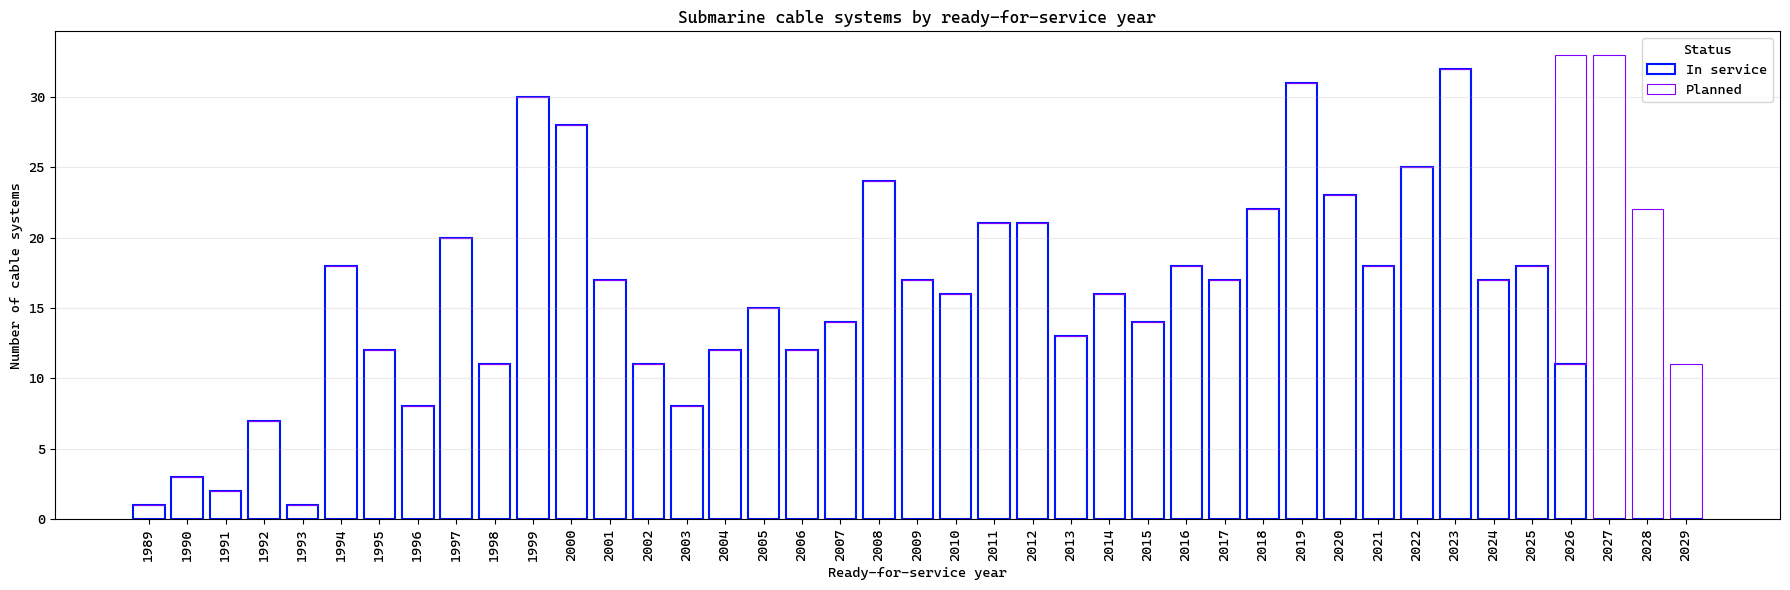

Cable records without an RFS year: 5


In [15]:
yearly = (
    metadata.dropna(subset=["rfs_year", "status"])
    .groupby(["rfs_year", "status"])
    .size()
    .unstack(fill_value=0)
    .sort_index()
)

x = range(len(yearly.index))
in_service = yearly.get("In service", pd.Series(0, index=yearly.index))
planned = yearly.get("Planned", pd.Series(0, index=yearly.index))

fig, ax = plt.subplots(figsize=(18, 6), facecolor="white")
ax.set_facecolor("white")
ax.bar(
    x,
    in_service,
    width=0.82,
    facecolor="none",
    edgecolor="#0015FF",
    linewidth=1.5,
    label="In service",
)
ax.bar(
    x,
    planned,
    bottom=in_service,
    width=0.82,
    facecolor="none",
    edgecolor="#8300FF",
    linewidth=0.8,
    label="Planned",
)
ax.set_title("Submarine cable systems by ready-for-service year")
ax.set_xlabel("Ready-for-service year")
ax.set_ylabel("Number of cable systems")
ax.legend(title="Status")

ax.set_xticks(list(x))
ax.set_xticklabels(yearly.index.astype(str), rotation=90, ha="center", va="top")
ax.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.show()

print(f"Cable records without an RFS year: {metadata['rfs_year'].isna().sum():,}")


## 7. Non-map visualization: operational status

This summary distinguishes currently mapped in-service systems from planned systems.
It describes the database snapshot, not the probability that each planned project will
be completed.


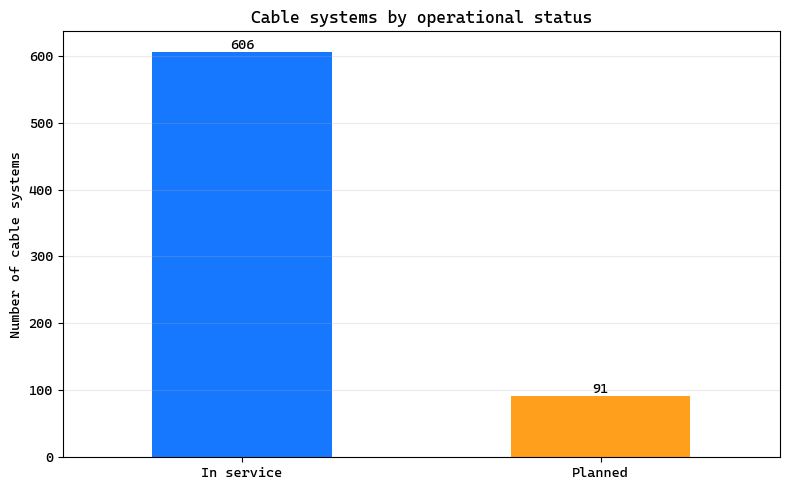

In [11]:
status_counts = metadata["status"].fillna("Unknown").value_counts()

ax = status_counts.plot(
    kind="bar",
    figsize=(8, 5),
    color=["#1677ff", "#ff9f1c", "#9aa4af"][:len(status_counts)],
)
ax.set_title("Cable systems by operational status")
ax.set_xlabel("")
ax.set_ylabel("Number of cable systems")
ax.bar_label(ax.containers[0])
ax.grid(axis="y", alpha=0.25)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


## 8. What these attributes can and cannot tell us

### What they can tell us

- The route geometries show the broad global pattern of documented submarine cable
  infrastructure and the concentration of mapped corridors.
- `rfs_year` supports a historical view of when systems entered, or are expected to
  enter, service.
- `is_planned` separates prospective systems from systems classified as operational in
  this API snapshot.
- Cable length and landing-point metadata can support further comparisons of system
  scale and international reach.

### What they cannot tell us

- The map does not measure bandwidth, traffic volume, latency, utilization, reliability,
  or the economic importance of a route.
- Route lines are generalized public representations, not engineering-grade coordinates
  of the cable on the seabed.
- Overlapping lines do not necessarily share the same physical trench or risk exposure.
- The dataset is maintained by TeleGeography and may omit confidential, domestic,
  decommissioned, or recently changed systems.
- Planned status and future RFS dates do not guarantee project completion.
- A dense map around a country does not by itself demonstrate equal internet access for
  people within that country; terrestrial networks, pricing, governance, and last-mile
  infrastructure are not represented.


## 9. Preliminary conclusion

The submarine cable network is global but spatially uneven. Its mapped corridors reflect
the need to connect coastal landing points across oceans, while the RFS timeline shows
that the network is continually renewed and expanded. The analysis is best understood as
a description of the physical systems represented in a specific API snapshot—not as a
direct map of global internet capacity, use, or access.

**Next analytical step:** use the landing-point countries to compare how many cable
systems connect to each country, while carefully distinguishing the number of systems
from actual network capacity.
